# Layer probing - where is the signal eaten, and is it recoverable?

Two questions for one signal:
1. **Where** does the patch tokeniser create degeneracy (redundancy / rank), and
2. **Is it recoverable** downstream? We prove it is NOT, with the one-patch-shift test:
   on an integer-cpp signal `x[n+P]=x[n]`, so a signal and its one-patch-advanced copy produce the
   *identical* token sequence. If the patcher maps two different time positions to the same tokens,
   no later layer can tell them apart - the encoder's rank-rise is only positional re-labelling, not
   recovery of lost signal content.

## Setup

In [258]:
import torch, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
np.random.seed(42); torch.manual_seed(42)

OUT = Path("../outputs/"); OUT.mkdir(parents=True, exist_ok=True)
SIGNALS_DIR = "../data/synthetic/signals/"

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
N_ENC, N_DEC = len(model.encoder.block), len(model.decoder.block)
print(f"P={P} S={S_DEF} pred_len={PRED_LEN} enc={N_ENC} dec={N_DEC}")

P=16 S=16 pred_len=64 enc=4 dec=4


## 1 - Choose one signal
`PICK`: filename substring or index. Use a blind-spot signal (`cpp1`) to see the effect.

In [259]:
files = sorted(f for f in os.listdir(SIGNALS_DIR) if f.endswith(".npy"))
PICK = "KernelSynth_J5_l_syn512_fs256_jitter0.0001__cpp7.9_amp0.03_ph1.5708.npy"                       # off-grid control
chosen = files[PICK] if isinstance(PICK, int) else next(f for f in files if PICK in f)
signal = np.load(os.path.join(SIGNALS_DIR, chosen)).astype(float).ravel()
ctx = signal[:512]
print("chosen:", chosen, "| len", len(signal))

chosen: KernelSynth_J5_l_syn512_fs256_jitter0.0001__cpp7.9_amp0.03_ph1.5708.npy | len 512


## 2 - Derived quantities (the formula reference)

In [260]:
def parse_name(f):
    grab = lambda p, c=float: (c(re.search(p, f).group(1)) if re.search(p, f) else None)
    return dict(generator="KernelSynth" if "kernelsynth" in f.lower() else "TSMixup",
                cpp=grab(r"_cpp([0-9.]+)"), hz=grab(r"_hz([0-9.]+)"),
                fs=grab(r"_fs([0-9]+)", int) or 256, phase=grab(r"_ph([0-9.]+)") or 0.0)

def injected_cpp(m):
    return m["cpp"] if m["cpp"] is not None else (m["hz"]*P/m["fs"] if m["hz"] is not None else None)

def _safe_num(pattern, text, cast=float, default=None):
    m = re.search(pattern, text)
    if not m:
        return default
    return cast(m.group(1).rstrip("."))

meta = {
    "generator": "KernelSynth" if "kernelsynth" in chosen.lower() else "TSMixup",
    "cpp": _safe_num(r"_cpp([0-9.]+)(?=_[A-Za-z]|\.npy$)", chosen),
    "hz": _safe_num(r"_hz([0-9.]+)(?=_[A-Za-z]|\.npy$)", chosen),
    "fs": _safe_num(r"_fs([0-9]+)(?=_[A-Za-z]|\.npy$)", chosen, int) or 256,
    "phase": _safe_num(r"_ph([0-9.]+)(?=_[A-Za-z]|\.npy$)", chosen) or 0.0,
}
cpp = injected_cpp(meta)
near = lambda v: abs(v-round(v)) < 1e-6
cls = "n/a"
if cpp is not None:
    f = cpp*meta["fs"]/P
    cls = "BLIND (on grid)" if (near(cpp) and 1<=round(cpp)<=P//2) else "off-grid / safe"
    if cpp != 0:
        f = cpp*meta["fs"]/P
        print(f"cpp={cpp}  f={f:.1f} Hz  T0={P/cpp:.1f} samples  phase={meta['phase']:.2f}  -> {cls}")
    else:
        print(f"No injection metadata found  -> {cls}")
    print(f"blind-spot cpp values m*P/S: {[m*P/S_DEF for m in range(1, S_DEF//2+1)]}")

cpp=7.9  f=126.4 Hz  T0=2.0 samples  phase=1.57  -> off-grid / safe
blind-spot cpp values m*P/S: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


## 3 - Capture every Chronos stage

In [261]:
def cut_into_patches(x, P, S): return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])
def adjacent_cos(M):
    M = np.asarray(M, float)
    s = [np.dot(M[i], M[i+1])/(np.linalg.norm(M[i])*np.linalg.norm(M[i+1])+1e-12) for i in range(len(M)-1)]
    return float(np.mean(s)) if s else np.nan
def effective_rank(M):
    M = np.asarray(M, float); M = M - M.mean(0, keepdims=True)
    sv = np.linalg.svd(M, compute_uv=False); sv = sv[sv > 1e-12]
    if sv.size == 0: return 0.0
    p = sv/sv.sum(); return float(np.exp(-(p*np.log(p)).sum()))
def as_matrix(t):
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy(); return a[0] if a.ndim == 3 else a

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride
    def save(key, use_in=False):
        def hook(m, i, o): cap[key] = as_matrix(i[0] if use_in else o)
        return hook
    if hasattr(model, "instance_norm"): handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"): handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad(): fc = pipeline.predict(x, prediction_length=PRED_LEN)
    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF
    scaled_1d = cap.pop("scaled", None)        # pop so the spread does not re-overwrite it
    cap = {"input": cut_into_patches(context, P, stride),
           "scaled": cut_into_patches(np.asarray(scaled_1d).ravel(), P, stride)
                     if scaled_1d is not None else cut_into_patches(context, P, stride), **cap}
    return fc, cap

forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
print("captured:", {s: cap[s].shape for s in STAGES})

captured: {'input': (32, 16), 'scaled': (32, 16), 'patched': (32, 16), 'pre_embed': (32, 32), 'post_embed': (32, 256), 'enc0': (33, 256), 'enc1': (33, 256), 'enc2': (33, 256), 'enc3': (33, 256), 'dec0': (1, 256), 'dec1': (1, 256), 'dec2': (1, 256), 'dec3': (1, 256), 'dec_out': (1, 256)}


## 4 - Where is it eaten (redundancy + effective rank)

Redundancy ~1 at `patched` = identical patches (degeneracy created at tokenisation, before any learned
layer). The encoder then lowers redundancy and raises rank - but **this is positional encoding making
*token positions* distinct, not recovery of the collapsed signal content**. Section 5 proves that.

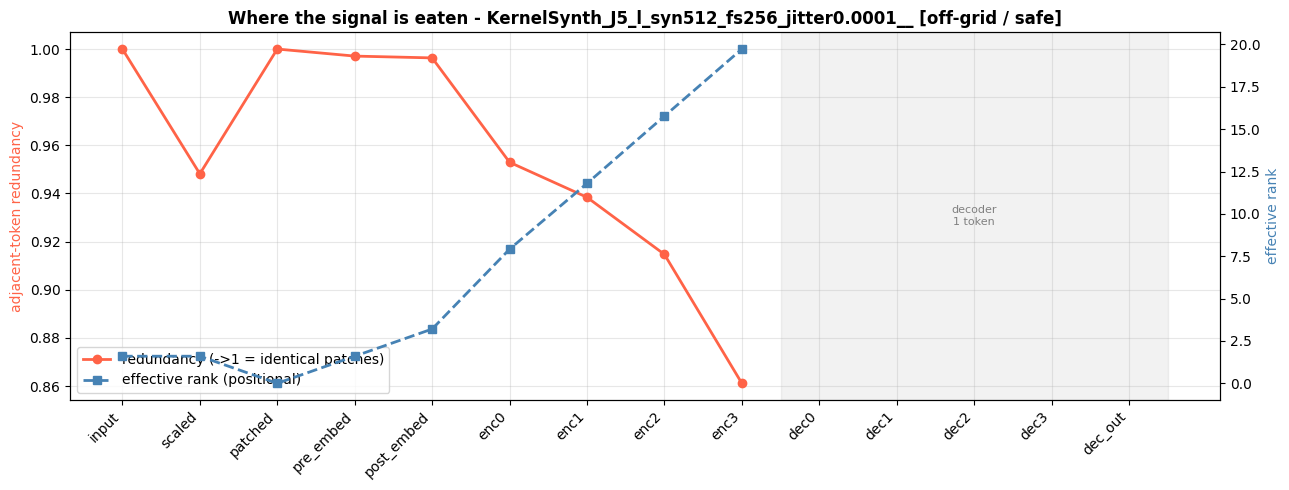

In [262]:
def stage_metrics(M):
    n = len(M)
    if n < 3: return dict(n_tokens=n, redundancy=np.nan, eff_rank=np.nan)
    return dict(n_tokens=n, redundancy=adjacent_cos(M), eff_rank=effective_rank(M))

prof = pd.DataFrame([{"stage": s, **stage_metrics(cap[s])} for s in STAGES])
fig, ax = plt.subplots(figsize=(13, 5)); ax2 = ax.twinx(); xs = np.arange(len(STAGES))
few = prof["redundancy"].isna().values
if few.any():
    ax.axvspan(xs[few].min()-0.5, xs[few].max()+0.5, color="grey", alpha=0.10)
    ax.text(xs[few].mean(), 0.5, "decoder\n1 token", ha="center", va="center", fontsize=8,
            color="grey", transform=ax.get_xaxis_transform())
ax.plot(xs, prof["redundancy"], "o-", color="tomato", lw=2, label="redundancy (->1 = identical patches)")
ax2.plot(xs, prof["eff_rank"], "s--", color="steelblue", lw=2, label="effective rank (positional)")
ax.set_xticks(xs); ax.set_xticklabels(STAGES, rotation=45, ha="right")
ax.set_ylabel("adjacent-token redundancy", color="tomato"); ax2.set_ylabel("effective rank", color="steelblue")
ax.set_title(f"Where the signal is eaten - {chosen[:44]} [{cls}]", fontweight="bold")
l1,a1=ax.get_legend_handles_labels(); l2,a2=ax2.get_legend_handles_labels(); ax.legend(l1+l2,a1+a2)
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig(OUT/"L1_layer_profile.png", dpi=140, bbox_inches="tight"); plt.show()

## 5 - Is it recoverable? The one-patch-shift test (the proof)

Compare the captured tokens of `x` against those of `x` advanced by exactly one patch (`roll(x, P)`).
At an integer cpp, `x[n+P]=x[n]`, so the two are identical at `patched` - and therefore at **every**
later stage, because any function gives identical outputs on identical inputs. A distance that stays
~0 from `patched` onward is the proof that the loss is **irreversible**: the encoder cannot recover what
the patcher merged. On an off-grid signal the distance stays large (the shift is observable).

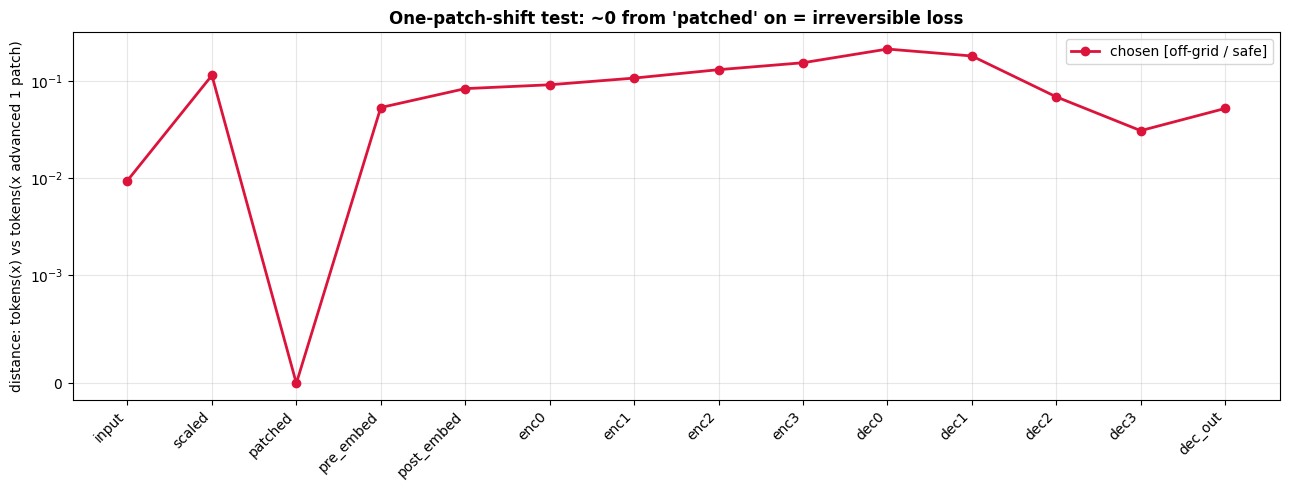

distance at 'patched' = 0.00e+00  (==0 => indistinguishable)
distance at last stage = 5.21e-02  (stays ~0 => encoder did NOT recover it)


In [263]:
def stage_dist(a, b):
    m = min(len(a), len(b)); a, b = np.asarray(a[:m], float), np.asarray(b[:m], float)
    return float(np.abs(a-b).mean() / (np.abs(a).mean() + np.abs(b).mean() + 1e-9))

_, cap_shift = forward_capture(np.roll(ctx, P))            # x advanced by one patch
D_chosen = [stage_dist(cap[s], cap_shift[s]) for s in STAGES]

# off-grid reference for contrast, if present
ref_file = next((f for f in files if "_cpp1.5" in f), None)
D_ref = None
if ref_file:
    rctx = np.load(os.path.join(SIGNALS_DIR, ref_file)).astype(float).ravel()[:512]
    _, cap_r = forward_capture(rctx); _, cap_rs = forward_capture(np.roll(rctx, P))
    D_ref = [stage_dist(cap_r[s], cap_rs[s]) for s in STAGES]

fig, ax = plt.subplots(figsize=(13, 5)); xs = np.arange(len(STAGES))
ax.plot(xs, D_chosen, "o-", color="crimson", lw=2, label=f"chosen [{cls}]")
if D_ref is not None: ax.plot(xs, D_ref, "s--", color="seagreen", lw=2, label="off-grid ref (cpp~1.5)")
ax.set_yscale("symlog", linthresh=1e-3)
ax.set_xticks(xs); ax.set_xticklabels(STAGES, rotation=45, ha="right")
ax.set_ylabel("distance: tokens(x) vs tokens(x advanced 1 patch)")
ax.set_title("One-patch-shift test: ~0 from 'patched' on = irreversible loss", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT/"L1_shift_irreversibility.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"distance at 'patched' = {D_chosen[STAGES.index('patched')]:.2e}  (==0 => indistinguishable)")
print(f"distance at last stage = {D_chosen[-1]:.2e}  (stays ~0 => encoder did NOT recover it)")

## 6b - Injection recovery: where exactly is the injected component lost?

The previous sections proved that a **one-patch shift** is irrecoverable from `patched` onward.
This section asks a sharper question: can we track the **injected sinusoidal component** specifically,
stage by stage, and pinpoint where it becomes undetectable?

**Metric — template correlation:**  
For each stage we project the token matrix onto its first principal component (`scores`, shape T),
then compute |Pearson r| against the expected template:

    template[i] = sin(2π · cpp · i · S/P + phase),  i = patch index

*Why this captures the blind spot analytically:*  
For integer `cpp` with `S = P`, `template[i] = sin(2π · m · i + phase) = const` for all integer i
→ template has zero variance → r = 0 **by definition**, before the model even runs.  
The injected frequency corresponds to `cpp` cycles per token in token-space — beyond the token-Nyquist
of `0.5 · P/S` cpp — so it is **structurally aliased at tokenisation**.

**Two-panel output:**
- *Left:* |r| across every pipeline stage for the chosen (blind) and off-grid reference signal.
- *Right:* Token-domain spectrum of the first PC at key stages; the injected cpp and the
  token-Nyquist boundary are marked — showing the injected frequency falls in the aliased zone.


c:\Users\Federico\DesktopW\patchAliasing\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Federico\DesktopW\patchAliasing\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


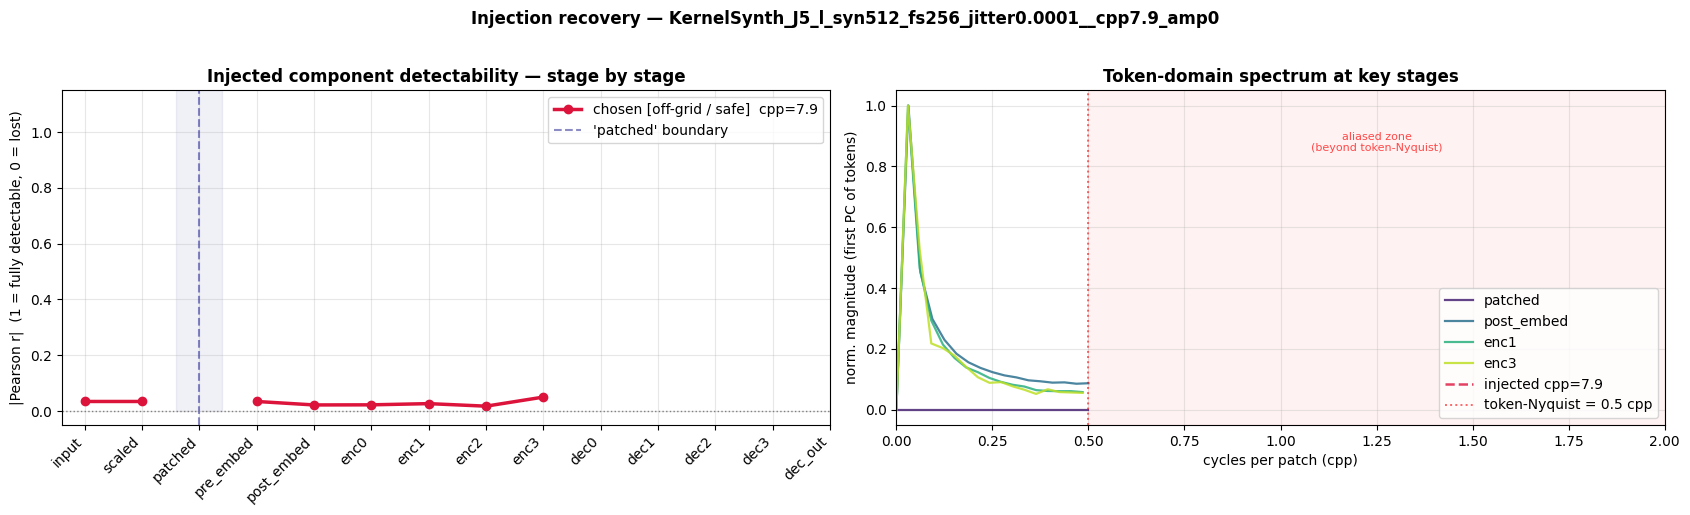


Injection recovery summary
  injected cpp       = 7.9  |  token-Nyquist = 0.5 cpp
  aliased in token space: True
  detectability @ patched : nan  (0 = blind spot)
  detectability @ dec_out : nan


In [264]:
from numpy.linalg import svd as _svd

# ── helpers ──────────────────────────────────────────────────────────────────
def first_pc_scores(M):
    """Project token matrix (T, D) onto its first PC; returns 1-D array length T."""
    M = np.asarray(M, float)
    if M.ndim == 1 or M.shape[1] == 1:
        return M.ravel()
    Mc = M - M.mean(0, keepdims=True)
    _, _, Vt = _svd(Mc, full_matrices=False)
    return Mc @ Vt[0]

def inject_template(n_tokens, cpp, S, P, phase=0.0):
    """
    Expected sinusoid at each patch start in patch-index space.
    For integer cpp with S=P  ->  sin(2π·m·i) = 0  for all integer i  ->  constant  ->  blind spot.
    """
    i = np.arange(n_tokens)
    return np.sin(2 * np.pi * cpp * i * S / P + phase)

def inject_detectability(M, cpp, S, P, phase=0.0):
    """
    |Pearson r| between first PC of token matrix and the injected template.
    Returns 0.0 when the template is constant (blind spot).
    Returns NaN when too few tokens.
    """
    M = np.asarray(M, float)
    T = M.shape[0]
    if T < 3:
        return np.nan
    scores  = first_pc_scores(M)
    tmpl    = inject_template(T, cpp, S, P, phase)
    if np.std(tmpl) < 1e-9:      # template is constant -> blind spot by definition
        return 0.0
    scores  = scores  - scores.mean()
    r = np.corrcoef(scores, tmpl)[0, 1]
    return float(abs(r))

# ── only run if the signal has injection metadata ─────────────────────────────
if cpp is None:
    print("No injection metadata in filename — skipping injection recovery plot.")
else:
    phase_chosen = meta.get("phase", 0.0)
    token_nyquist_cpp = 0.5 * P / S_DEF   # cpp value at token-domain Nyquist

    # detectability for chosen signal
    det_chosen = [inject_detectability(cap[s], cpp, S_DEF, P, phase_chosen) for s in STAGES]

    # detectability for off-grid reference (reuse cap_r from §5 if available)
    det_ref, cpp_ref = None, None
    if ref_file:
        meta_ref = parse_name(ref_file)
        cpp_ref  = injected_cpp(meta_ref)
        phase_ref = meta_ref.get("phase", 0.0)
        det_ref  = [inject_detectability(cap_r[s], cpp_ref, S_DEF, P, phase_ref) for s in STAGES]

    # ── figure ───────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    xs = np.arange(len(STAGES))
    patch_x = STAGES.index("patched")

    # ---- Panel 1: detectability per stage ----
    ax1.plot(xs, det_chosen, "o-", color="crimson", lw=2.5,
             label=f"chosen [{cls}]  cpp={cpp}")
    if det_ref is not None:
        ax1.plot(xs, det_ref, "s--", color="seagreen", lw=2.0,
                 label=f"off-grid ref  cpp={cpp_ref:.2g}")
    ax1.axvline(patch_x, color="navy", ls="--", alpha=0.45, lw=1.5, label="'patched' boundary")
    ax1.axhline(0, color="grey", ls=":", lw=1)
    ax1.fill_betweenx([0, 1.15], patch_x - 0.4, patch_x + 0.4, color="navy", alpha=0.06)
    ax1.set_xticks(xs); ax1.set_xticklabels(STAGES, rotation=45, ha="right")
    ax1.set_ylabel("|Pearson r|  (1 = fully detectable, 0 = lost)")
    ax1.set_ylim(-0.05, 1.15)
    ax1.set_title("Injected component detectability — stage by stage", fontweight="bold")
    ax1.legend(loc="upper right"); ax1.grid(alpha=0.3)
    # annotate blind-spot collapse
    if cls.startswith("BLIND"):
        ax1.annotate("template constant\n→ r = 0 by construction",
                     xy=(patch_x, 0.02), xytext=(patch_x + 1.2, 0.22),
                     arrowprops=dict(arrowstyle="->", color="navy"),
                     fontsize=8, color="navy")

    # ---- Panel 2: token-domain spectrum at key stages ----
    key_stages = [s for s in ["patched", "post_embed", "enc1", f"enc{N_ENC-1}"] if s in cap]
    colors_spec = plt.cm.viridis(np.linspace(0.1, 0.9, len(key_stages)))
    for col, stage in zip(colors_spec, key_stages):
        M = np.asarray(cap[stage], float)
        T = M.shape[0]
        if T < 4:
            continue
        scores = first_pc_scores(M); scores -= scores.mean()
        fft_mag = np.abs(np.fft.rfft(scores))
        # x-axis: cycles per patch (cpp units)
        freqs_cpp = np.fft.rfftfreq(T) * P / S_DEF
        fft_mag /= (fft_mag.max() + 1e-9)
        ax2.plot(freqs_cpp, fft_mag, lw=1.6, alpha=0.85, color=col, label=stage)

    ax2.axvline(cpp, color="crimson", ls="--", lw=1.8, alpha=0.8,
                label=f"injected cpp={cpp}")
    ax2.axvline(token_nyquist_cpp, color="red", ls=":", lw=1.4, alpha=0.6,
                label=f"token-Nyquist = {token_nyquist_cpp:.2g} cpp")
    ax2.set_xlabel("cycles per patch (cpp)")
    ax2.set_ylabel("norm. magnitude (first PC of tokens)")
    ax2.set_xlim(0, min(P // 2, token_nyquist_cpp * 4))
    ax2.set_title("Token-domain spectrum at key stages", fontweight="bold")
    ax2.legend(); ax2.grid(alpha=0.3)
    if cpp >= token_nyquist_cpp:
        ax2.axvspan(token_nyquist_cpp, ax2.get_xlim()[1], color="red", alpha=0.05,
                    label="_aliased zone")
        ax2.text((token_nyquist_cpp + ax2.get_xlim()[1]) / 2, 0.85,
                 "aliased zone\n(beyond token-Nyquist)",
                 ha="center", fontsize=8, color="red", alpha=0.7)

    plt.suptitle(f"Injection recovery — {chosen[:55]}", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUT / "L1_injection_recovery.png", dpi=140, bbox_inches="tight")
    plt.show()

    # ── summary ──────────────────────────────────────────────────────────────
    pi_idx = STAGES.index("patched")
    print(f"\nInjection recovery summary")
    print(f"  injected cpp       = {cpp}  |  token-Nyquist = {token_nyquist_cpp:.3g} cpp")
    print(f"  aliased in token space: {cpp >= token_nyquist_cpp}")
    print(f"  detectability @ patched : {det_chosen[pi_idx]:.3f}  (0 = blind spot)")
    print(f"  detectability @ {STAGES[-1]:8s}: {det_chosen[-1]:.3f}")
    if det_ref is not None:
        print(f"  off-grid ref  @ patched : {det_ref[pi_idx]:.3f}")
        print(f"  off-grid ref  @ {STAGES[-1]:8s}: {det_ref[-1]:.3f}")


## 6 - Spectral round-trip (decoder = single token, judged by its forecast)

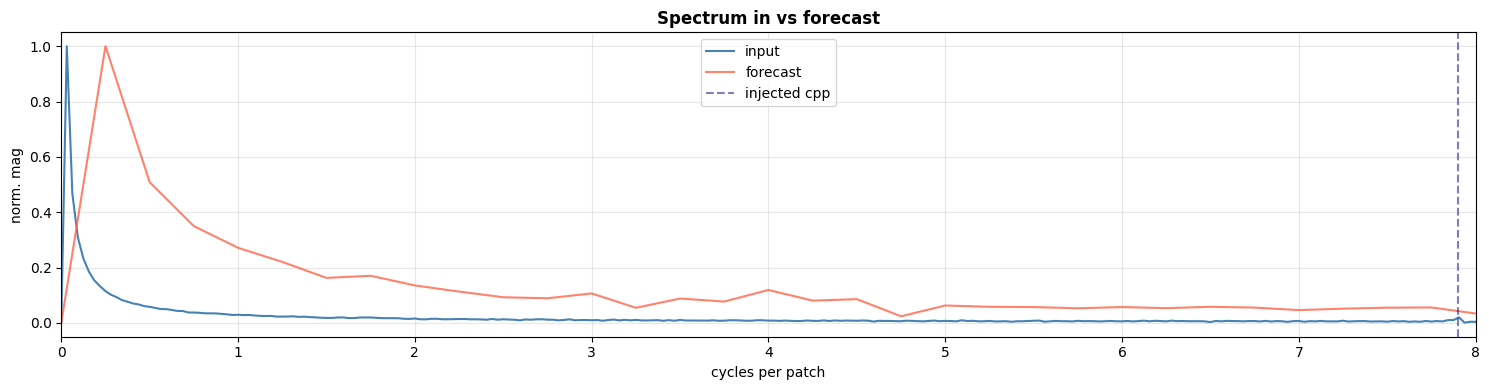

In [269]:
pred = forecast[0].median(dim=0).values.numpy(); truth = signal[512:512+PRED_LEN]
def spec(x):
    x = np.asarray(x, float)-np.mean(x); m = np.abs(np.fft.rfft(x)); return np.fft.rfftfreq(len(x))*P, m
cin, mi = spec(ctx); cout, mo = spec(pred)
plt.figure(figsize=(15, 4))
plt.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
plt.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.8, label="forecast")
if cpp: plt.axvline(cpp, color="navy", ls="--", alpha=.5, label="injected cpp")
plt.xlim(0, P/2)
plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast", fontweight="bold"); plt.legend(); plt.grid(alpha=.3)

plt.tight_layout(); plt.savefig(OUT/"L1_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()




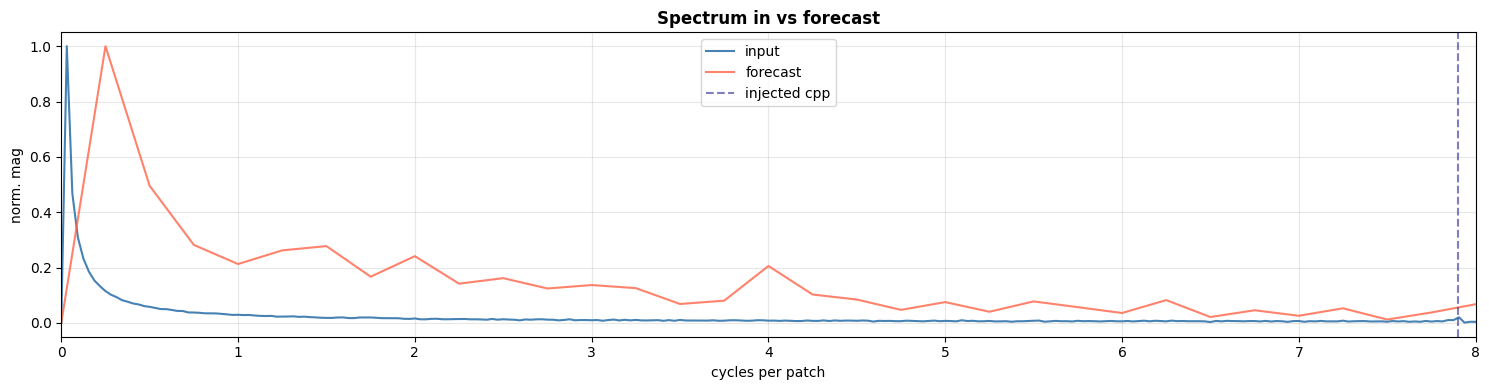

In [270]:
pred = forecast[0][0].numpy(); truth = signal[512:512+PRED_LEN]
# the 9 quantiles of chronos forecast corresponds to the 9 "samples" dimension in forecast[0], so we take the first one for a deterministic reference; using the median across quantiles gives a very similar spectrum but is less "clean" (more high-freq noise), presumably because the quantiles are not perfectly aligned in phase and thus do not reinforce each other as well as a single sample would
# each quantile is a different "sample" from the model's predictive distribution, so they are not perfectly in phase and thus their median has more high-freq noise than a single sample would; but the overall spectral shape is very similar and the injected cpp is still visible, just less cleanly
def spec(x):
    x = np.asarray(x, float)-np.mean(x); m = np.abs(np.fft.rfft(x)); return np.fft.rfftfreq(len(x))*P, m
cin, mi = spec(ctx); cout, mo = spec(pred)
plt.figure(figsize=(15, 4))
plt.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
plt.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.8, label="forecast")
if cpp: plt.axvline(cpp, color="navy", ls="--", alpha=.5, label="injected cpp")
plt.xlim(0, P/2)
plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast", fontweight="bold"); plt.legend(); plt.grid(alpha=.3)

plt.tight_layout(); plt.savefig(OUT/"L1_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()




In [266]:
print("pred std:", np.std(pred))
print("pred min:", pred.min())
print("pred max:", pred.max())
print("pred first values:", pred[:20])

pred std: 0.013506218
pred min: 11.935673
pred max: 11.999227
pred first values: [11.935673  11.947129  11.94995   11.948803  11.952024  11.954895
 11.954348  11.954673  11.956977  11.961199  11.963514  11.963518
 11.969752  11.972801  11.969097  11.9574585 11.963771  11.971437
 11.97742   11.971938 ]


## 7 - Verdict

In [267]:
pi = prof.set_index("stage")
print(f"Signal           : {chosen}  [{cls}]")
print(f"Redundancy@patched: {pi.loc['patched','redundancy']:.3f}  (degeneracy born at tokenisation)")
print(f"Shift distance    : patched {D_chosen[STAGES.index('patched')]:.1e} -> final {D_chosen[-1]:.1e}")
print()
if cls.startswith("BLIND"):
    print("BLIND signal: the one-patch shift is indistinguishable from 'patched' onward.")
    print("=> the loss is ARCHITECTURAL and IRREVERSIBLE; the encoder's rank-rise is positional,")
    print("   it relabels token positions but cannot recover the merged signal content.")
    print("   Forecast MAE can still be low because a phase-locked tone is trivially periodic -")
    print("   the harm is the lost ability to tell WHERE in time the signal is, not next-step error.")
else:
    print("OFF-GRID signal: the shift stays observable downstream (distance > 0) - no structural loss.")

Signal           : KernelSynth_J5_l_syn512_fs256_jitter0.0001__cpp7.9_amp0.03_ph1.5708.npy  [off-grid / safe]
Redundancy@patched: 1.000  (degeneracy born at tokenisation)
Shift distance    : patched 0.0e+00 -> final 5.2e-02

OFF-GRID signal: the shift stays observable downstream (distance > 0) - no structural loss.
